# MODEL OVERVIEW
- 50 AL neurons
    - 20 of these are activated by a scent
    - Each AL neuron generates firing activity/current
- AL-MB weights 
- 2000 MB neurons (LIF)

Antennal lobe: AL 
Mushroom body: MB 

# Generating Odor Pattern & Spiking in neurons in antennal lobe layer

In [72]:
import numpy as np
import matplotlib.pyplot as plt
N_AL = 50              # Number of Antennal Lobes
N_ODOR_ACTIVE = 20     # Number of AL neurons each odor activates
N_MB = 2000            # Number of Mushroom Body neurons
N_OUTPUT = 1           # A single output neuron for avoidance decision
rng = np.random.default_rng(seed=123) # Creates a random number generator, seed included for reproducibility, set to None for a truly random simulation

# Initialize empty arrays
#output_history = [] 
#w_mb_out_history = []

### 1) Function for generating a unique odor pattern

In [73]:
def make_odor(N_AL, N_ODOR_ACTIVE, rng):
    """
    Return a unique odor pattern of length n_al with n_odor_active neurons set to 1.

    Args: 
        N_AL: An integer representing the number of antennal lobe neurons 
        N_ODOR_ACTIVE: An integer representing the number of AL neurons each odor activates 
        seed: An integer random seed for reproducibility (default: NONE) 

    Returns: 
        odor: A binary np.array of length N_AL, with N_ODOR_ACTIVE entries set to 1 representing a single odor pattern
    """
    odor = np.zeros(N_AL)             # Odor is initialized as an array of zeros of a length of the number of AL neurons.
    # Randomly picks some n_odor_active number to be active in the range of N_AL
    # e.g. 20 random (N_ODOR_ACTIVE) indices from range N_AL (1-50) are chosen to be active.
    active_indices = rng.choice(N_AL, size=N_ODOR_ACTIVE, replace=False) 
    odor[active_indices] = 1 # Set random indices in odor array to 1 to create a unique binary vector (i.e. a single odor pattern)
    return odor # returns uniqur odor pattern

### 2) Function for generating spiking in neurons within antennal lobe layer in response to 1 odor pattern

In [74]:
def generate_AL_spikes(odor, t, dt, spike_interval = 300):
    """
    Return a list of spike times for each AL neuron based on an odor activation pattern 

    Args: 
        odor: A binary np.array of length_AL
        t: An np.array of time in seconds 
        dt: A float representing the timesteps in seconds 
        spike_interval: An integer representing the number of timesteps between spikes (eg. 300 steps is a 2s trace)

    Returns: 
        AL_spikes: A list of N_AL arrays, each entry containing spike times in seconds. Inactive neurons have an empty array.
    """
    AL_spikes = [] # Initialize AL_spikes list as an empty array 
    for active in odor: 
        if active:
            spike_times = np.arange(0, len(t), spike_interval)  # Active neurons spike every 100 ms
            spike_times = spike_times * dt                      # Spike time converted to seconds
        else:
            spike_times = []   # If neuron inactive, neuron initialized as empty array.
        AL_spikes.append(spike_times) # Add neuron activity to overall AL_spike list
    return AL_spikes

### 3) Initialize odor and antennal lobe spiking patterns

In [75]:
# Intializing odor & AL_spike pattern 
# Odor
odor = make_odor(N_AL, N_ODOR_ACTIVE, rng)

# AL_spike pattern 
dt = 0.001                  # Timestep in seconds 
t = np.arange(0,2000)*dt    # Total time trace in seconds
t_total = 2000 * dt         # Total time in seconds
AL_spikes = generate_AL_spikes(odor, t, dt, spike_interval = 300)

### Optional sanity checks: Print statements of odor pattern, spike timing, and AL layer activation

In [76]:
print(f"Odor pattern: {odor}")
print(f"\nTotal simulation time: {t_total} seconds")
active_neurons = [i for i, spike_times in enumerate(AL_spikes) if len(spike_times) > 0] # Gets indices of randomly chosen active AL neurons
print(f"\nIndices of active AL neurons: {active_neurons}")
print("\nAL neuron spike times (for active neurons):")
for i, spike_times in enumerate(AL_spikes): # Prints spike times of each AL neuron (should be the same for all)
    if len(spike_times) > 0:
        print(f"Neuron {i}: {spike_times}")

Odor pattern: [1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1.
 1. 0.]

Total simulation time: 2.0 seconds

Indices of active AL neurons: [0, 1, 7, 9, 12, 13, 14, 19, 20, 21, 31, 34, 37, 39, 40, 42, 44, 46, 47, 48]

AL neuron spike times (for active neurons):
Neuron 0: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 1: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 7: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 9: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 12: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 13: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 14: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 19: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 20: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 21: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 31: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 34: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 37: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 39: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 40: [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Neuron 42: [0.  0.3 0.6 0.9 1.2 

### 4) Plot odor activation pattern next to active spike time series of active AL neurons

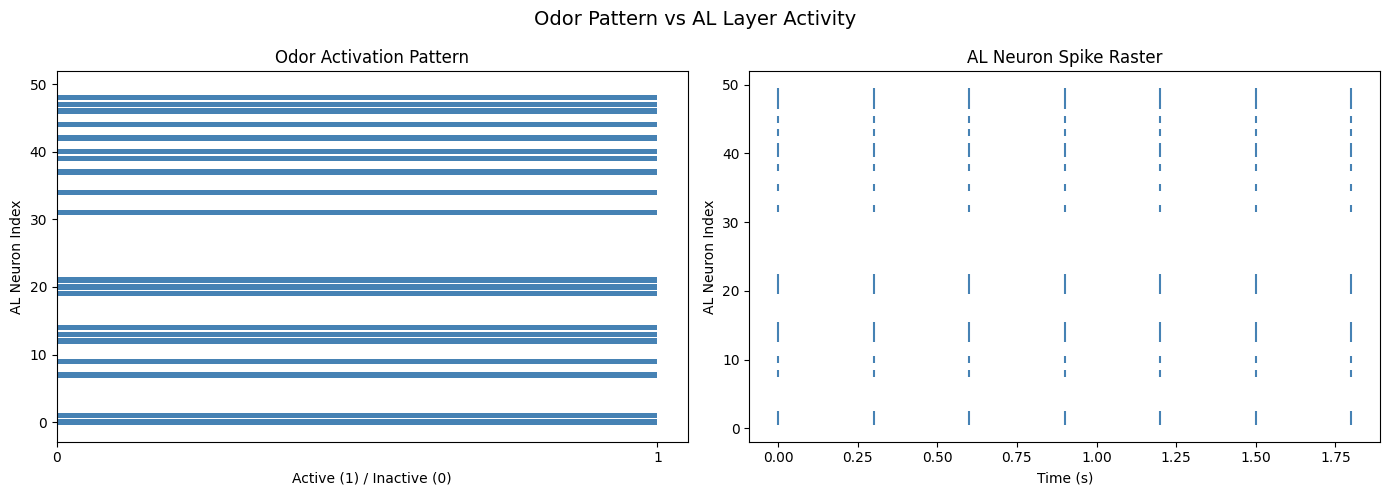

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # plots

# Left plot: Odor activation pattern
axes[0].barh(range(N_AL), odor, color='steelblue')
axes[0].set_ylabel('AL Neuron Index')
axes[0].set_xlabel('Active (1) / Inactive (0)')
axes[0].set_title('Odor Activation Pattern')
axes[0].set_xticks([0, 1])

# Right plot: raster plot for vertical spikes
for i, spike_times in enumerate(AL_spikes):
    axes[1].vlines(spike_times, i + 0.5, i + 1.5, color='steelblue')

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('AL Neuron Index')
axes[1].set_title('AL Neuron Spike Raster')

plt.suptitle('Odor Pattern vs AL Layer Activity', fontsize=14)
plt.tight_layout()
plt.show()

Graph Interpretation: The unique odor pattern indicates which neurons spike over a period of time. Spikes occur at the same time points across all chosen neurons.

# Antennal lobe to mushroom body neuron network 
Each AL neuron spike induces a current into the mushroom body neuron as expressed by equation 3 in the paper: 
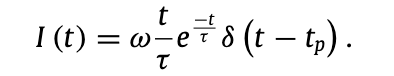

### 1) Function for computing presynaptic current generated by AL neuron to MB neuron

In [78]:
# need to edit to try to get current to generate spikes in some MB neurons
def alpha_current(t, spike_times, weight, tau=0.2):
    """
    Return a current generated by the spike times of an AL neuron

    Args: 
        t: An np.array of time in seconds 
        w: An integer representing the synaptic weight between pre and post synaptic sites 
        tau: An integer representing the synaptic time constant. The paper uses 0.2s.
        
    Returns: 
        I: An np.array of the current at each timestep
    """
    I = np.zeros_like(t) # Initializes I as an array of zeros with length of timestep t
    for tp in spike_times: # For each timepoint with a spike
        # Computes how much time has passed since spike time
        x = t - tp
        # Computes alpha function shape of current produced by a single spike
        kernel = (x / tau) * np.exp(-x / tau) 
        # All values before spike are set to 0
        kernel[x < 0] = 0 
        # Scales shape by synaptic weight and adds to running current
        I += weight * kernel
    return I

### 2) Initialize currents of inactive and active AL neuron

In [79]:
active_AL_neuron_index = np.random.choice(np.where(odor == 1)[0])  # Index of an active AL neuron (from the odor pattern)
inactive_AL_neuron_index = np.random.choice(np.where(odor == 0)[0])  # Index of an inactive AL neuron (from the odor pattern)

# Generate currents of chosen active and inactive neuron
I_AL_neuron_active = alpha_current(t, AL_spikes[active_AL_neuron_index], test_weight, 0.2) 
I_AL_neuron_inactive = alpha_current(t, AL_spikes[inactive_AL_neuron_index], test_weight, 0.2)

### 3) Plot current of an active and inactive AL neuron over time

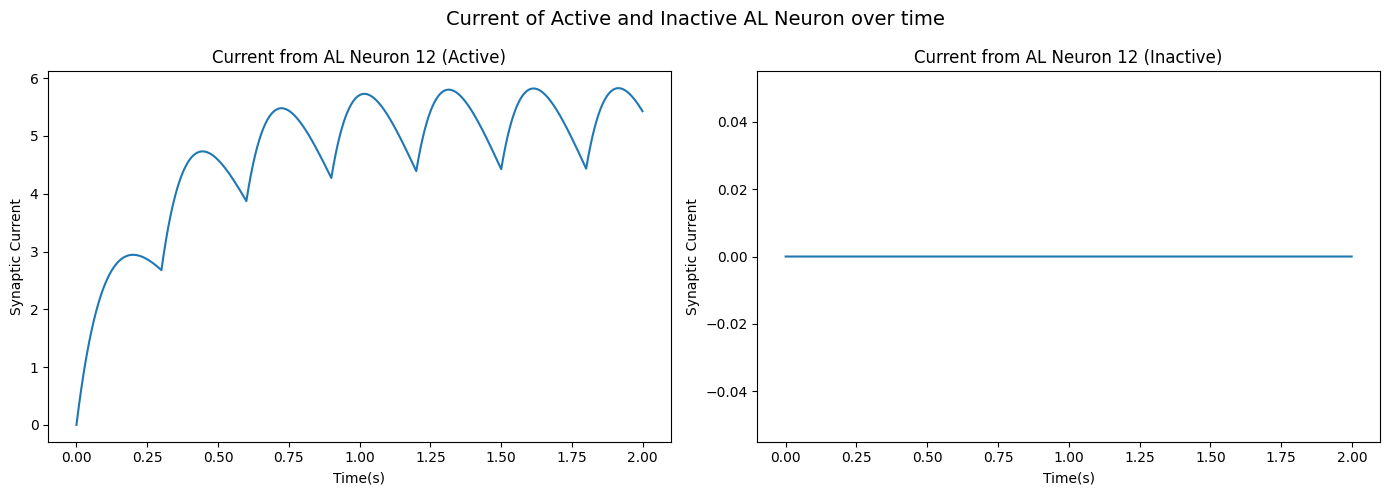

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # plots

# Left plot: Active
axes[0].plot(t,I_AL_neuron_active)
axes[0].set_xlabel('Time(s)')
axes[0].set_ylabel('Synaptic Current')
axes[0].set_title(f"Current from AL Neuron {active_AL_neuron_index} (Active)")

# Right plot: Inactive
axes[1].plot(t,I_AL_neuron_inactive)
axes[1].set_xlabel('Time(s)')
axes[1].set_ylabel('Synaptic Current')
axes[1].set_title(f"Current from AL Neuron {active_AL_neuron_index} (Inactive)")

plt.suptitle('Current of Active and Inactive AL Neuron over time', fontsize=14)
plt.tight_layout()
plt.show()

### Optional sanity checks: Print spike times of chosen active and inactive AL neuron

In [81]:
print(f"Spike times of AL neuron {active_AL_neuron_index} (active): {AL_spikes[active_AL_neuron_index]}")
print(f"Spike times of AL neuron {inactive_AL_neuron_index} (inactive): {AL_spikes[inactive_AL_neuron_index]}")

Spike times of AL neuron 12 (active): [0.  0.3 0.6 0.9 1.2 1.5 1.8]
Spike times of AL neuron 30 (inactive): []


In [82]:
### 4) Plot current of an active AL neuron across different AL-MB weights

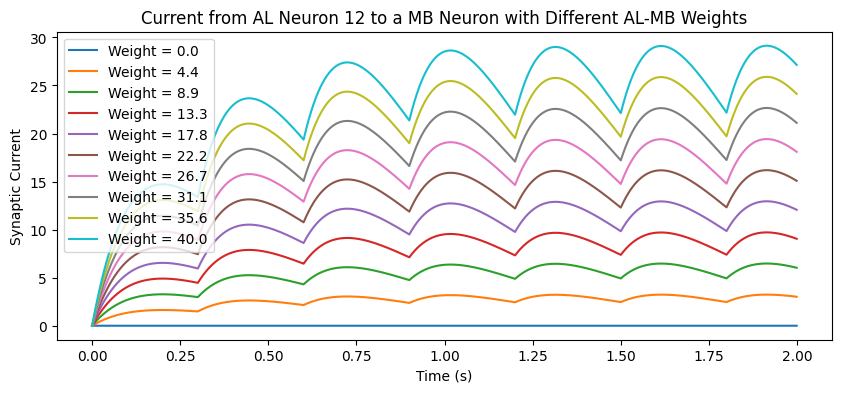

In [83]:
weights_to_test = np.linspace(0, 40, 10)  # Test weights from 1 to 40

# Generate currents with different weights for the same active AL neuron
plt.figure(figsize=(10, 4))
for n, w in enumerate(weights_to_test):
    I_AL_neuron_active = alpha_current(t, AL_spikes[active_AL_neuron_index], w, 0.2)
    plt.plot(t, I_AL_neuron_active, label=f'Weight = {w:.1f}')
plt.xlabel('Time (s)')
plt.ylabel('Synaptic Current')
plt.title('Current from AL Neuron ' + str(active_AL_neuron_index) +  ' to a MB Neuron with Different AL-MB Weights')
plt.legend()
plt.show()

Graph Interpretation: As synaptic weights increase, synaptic current from active AL neuron increases and current shape becomes more pronounced.

# Mushroom Body Layer
Mushroom Body takes in an input current and generates an input based on the 'Leaky Integerate and Fire; model. MB Parameters are set according to Table 1 in the paper: 
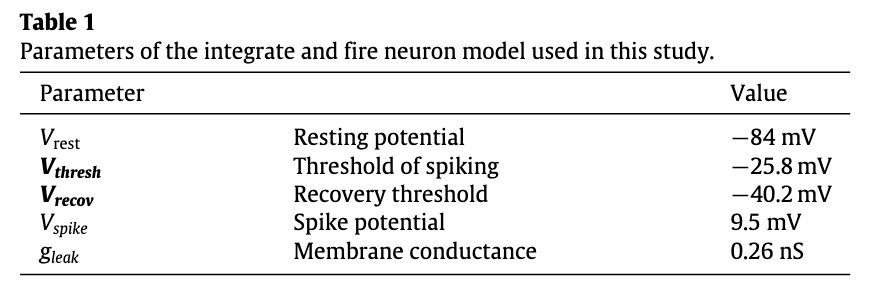

LIF Model is defined in equation 2: 

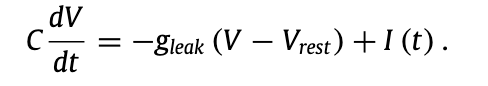

### 1) Function for defining LIF model

In [84]:
def LIF(I, V, dt):
    """
    Return a voltage generated by the LIF model.

    Args: 
        I: An np.array current time series
        V: An np.array membrane potential array, all initialized to V_rest
        dt: A float representing timesteps in seconds 

    Returns: 
        V: A np.array membrane potential time series in mV
        spikes: An np.array of length V where 1 means a spike in that timestep, and 0 being no spike
    """

    # Parameters set according to table 1
    V_rest = -84.0
    V_thresh = -25.8
    V_recov = -40.2
    V_spike = 9.5
    g_leak = 0.26
    C = 1.0
    
    V = np.full(len(V), V_rest) # Initialize V to be V_rest of length input V
    spikes = np.zeros(len(V))  # Initialize spikes to be an array of zeros of length input V

    for k in range(1, len(V) - 1):
        dV = (-g_leak * (V[k] - V_rest) + I[k]) / C # Based on equation of LIF model
        V[k + 1] = V[k] + dt * dV # Voltage in next time step is current voltage and change

        if V[k] >= V_thresh: # Spikes if over threshold
            V[k] = V_spike   # Current voltage is spike potential
            spikes[k] = 1    # Record spike
            V[k+1] = V_recov # Next voltage is recovery threshold

    return V, spikes

### 2) Define spiking of MB neurons based on input currents of AL neurons

In [85]:
# Set parameters
tau_syn = 0.2 # time constant tau = 0.2s
# Set I, V and spike arrays to be an array of zeros of the number of mushroom body neurons by length of t.
I_MB = np.zeros((N_MB, len(t)))
V_MB = np.zeros((N_MB, len(t)))
spikes_MB = np.zeros((N_MB, len(t)))
# random n_mb x n_al matrix of weights, 15 is arbitrarily set for neurons to spike. current model doesn't have updated weight adjustment
weights_AL_MB = rng.random((N_MB, N_AL)) * 15 

# Define spiking for current of MB Layer
for n in range(N_MB): # Loop over every mushroom body neuron
    for j in range(N_AL): # Loop over every antennal lobe neuron
        I_MB[n] += alpha_current(t, AL_spikes[j], weights_AL_MB[n, j], tau_syn) # adds alpha current from current AL neuron with adjusted weight matrix
    
    V_MB[n], spikes_MB[n] = LIF(I_MB[n], V_MB[n], dt)
    #print(f"MB Neuron {n} spike times: {t[spikes_MB[n] == 1]}")  # Print the spike times for each MB neuron
print("MB Layer simulation complete.")

MB Layer simulation complete.


### 3) Plot Weight distribution and spike count relationship

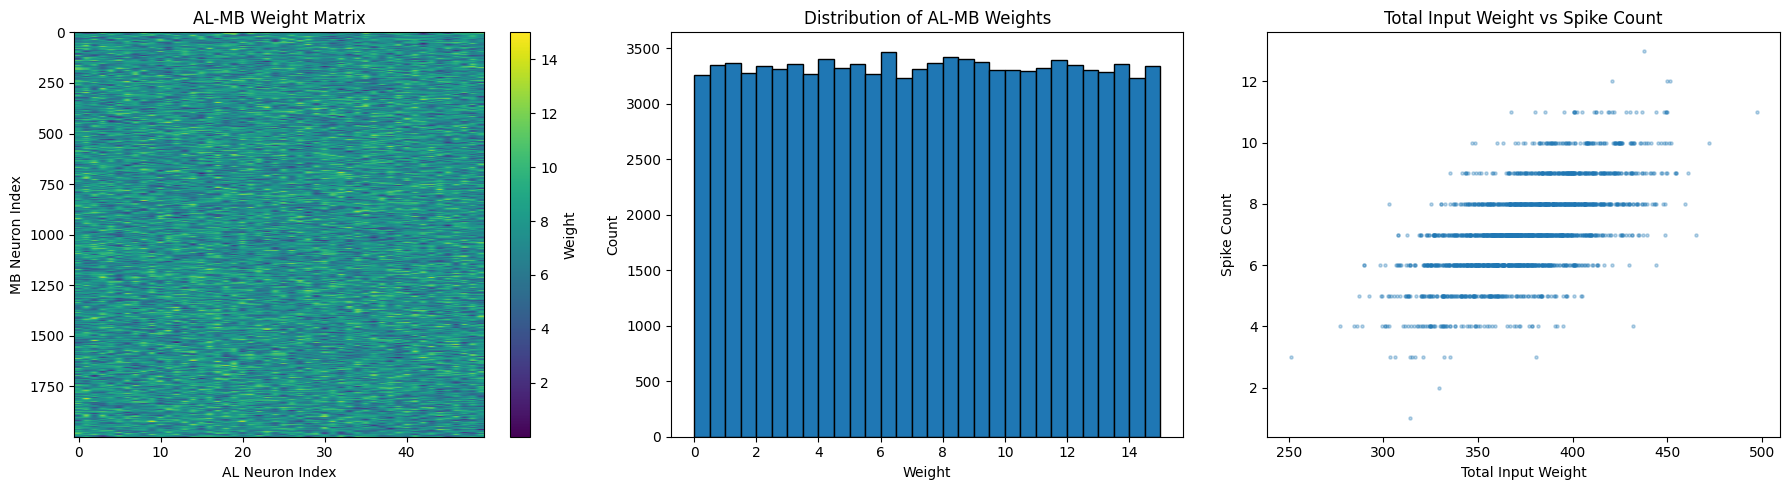

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: heatmap of AL-MB weights
im = axes[0].imshow(weights_AL_MB, aspect='auto', cmap='viridis')
axes[0].set_xlabel('AL Neuron Index')
axes[0].set_ylabel('MB Neuron Index')
axes[0].set_title('AL-MB Weight Matrix')
plt.colorbar(im, ax=axes[0], label='Weight')

# Middle: histogram of all weights
axes[1].hist(weights_AL_MB.flatten(), bins=30, edgecolor='black')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of AL-MB Weights')

# Right: scatter plot of total input current vs spike count
total_input_current = np.sum(weights_AL_MB, axis=1)
axes[2].scatter(total_input_current, spike_counts, alpha=0.3, s=5)
axes[2].set_xlabel('Total Input Weight')
axes[2].set_ylabel('Spike Count')
axes[2].set_title('Total Input Weight vs Spike Count')

plt.tight_layout()
plt.show()

### 4) Plot firing activity of MB neurons

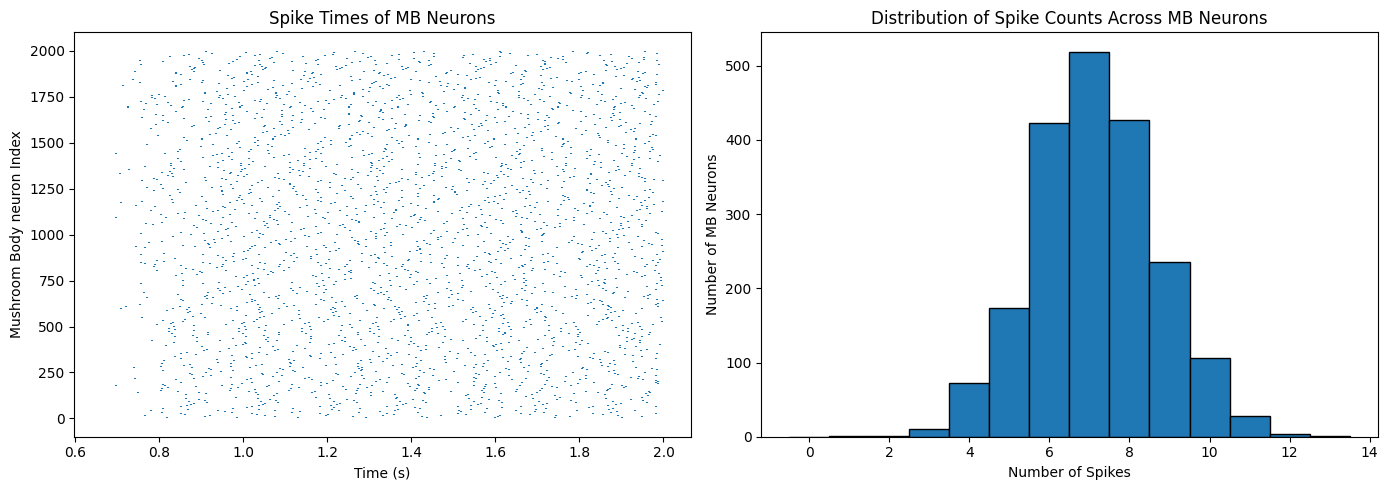

In [87]:
spike_counts = np.sum(spikes_MB, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raster plot of MB neuron spikes
for n in range(N_MB):
    axes[0].vlines(t[spikes_MB[n] == 1], n + 0.5, n + 1.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Mushroom Body neuron Index')
axes[0].set_title('Spike Times of MB Neurons')

# Right: histogram of spike counts
axes[1].hist(spike_counts, bins=np.arange(-0.5, np.max(spike_counts) + 1.5, 1), edgecolor='black')
axes[1].set_xlabel('Number of Spikes')
axes[1].set_ylabel('Number of MB Neurons')
axes[1].set_title('Distribution of Spike Counts Across MB Neurons')

plt.tight_layout()
plt.show()

### 5) Plot input current and membrane potential of MB neurons

In [88]:
# Collect example neurons based on activity level
active_MB_neuron = np.where(spike_counts == np.max(spike_counts))[0]  # Indices of active MB neurons (that spiked at least once)
less_active_MB_neuron = np.where(spike_counts == np.min(spike_counts))[0]  # Indices of less active MB neurons (that spiked less frequently)

# Sanity check for example collection 
if len(active_MB_neuron) == 0:
    print("No active MB neurons found.")
if len(less_active_MB_neuron) == 0:
    print("No inactive MB neurons found.")

# Choose a random neuron from active and inactive indices
active_MB_neuron = np.random.choice(active_MB_neuron)
less_active_MB_neuron = np.random.choice(less_active_MB_neuron)

print(f"Index of active MB neuron (spiked at least once): {active_MB_neuron}")
print(f"Index of less active MB neuron (spiked less frequently): {less_active_MB_neuron}")

Index of active MB neuron (spiked at least once): 797
Index of less active MB neuron (spiked less frequently): 118


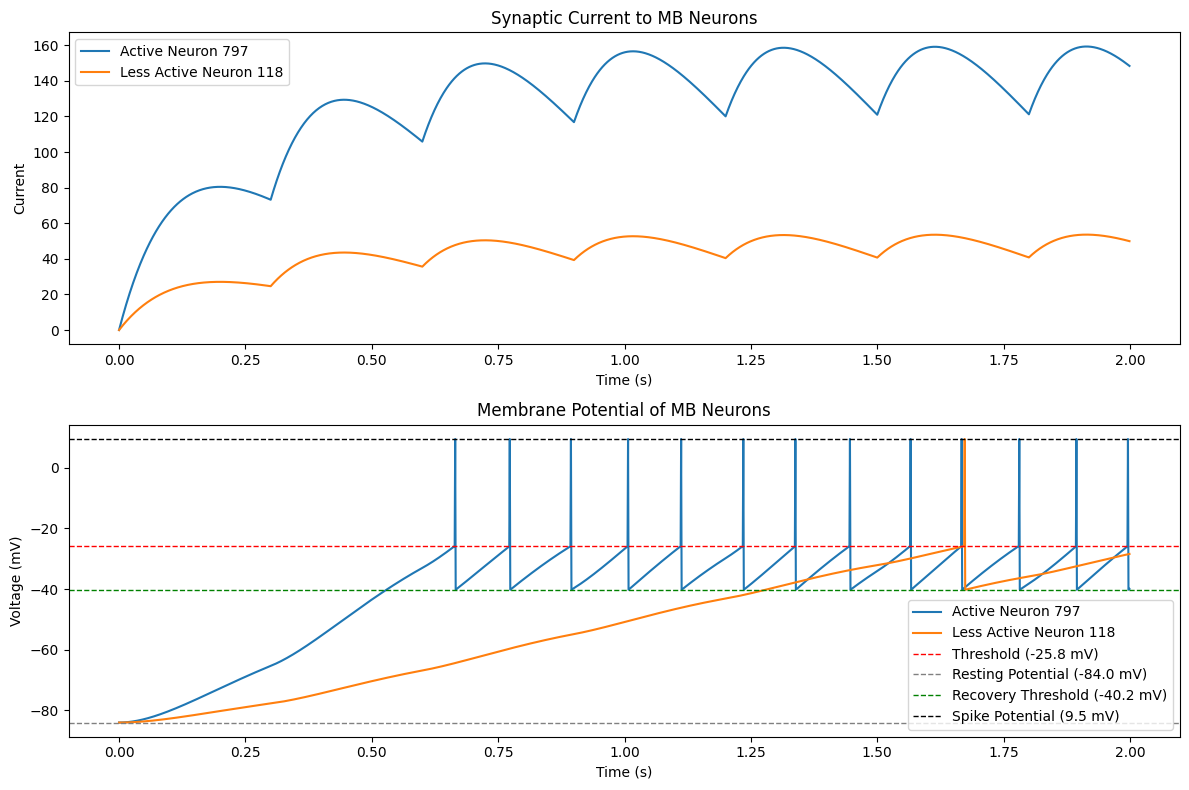

In [89]:
# Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Parameters set according to table 1
V_rest = -84.0
V_thresh = -25.8
V_recov = -40.2
V_spike = 9.5

# Top: synaptic current for both neurons
axes[0].plot(t, I_MB[active_MB_neuron], label=f'Active Neuron {active_MB_neuron}')
axes[0].plot(t, I_MB[less_active_MB_neuron], label=f'Less Active Neuron {less_active_MB_neuron}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Current')
axes[0].set_title('Synaptic Current to MB Neurons')
axes[0].legend()

# Bottom: membrane potential for both neurons
axes[1].plot(t, V_MB[active_MB_neuron], label=f'Active Neuron {active_MB_neuron}')
axes[1].plot(t, V_MB[less_active_MB_neuron], label=f'Less Active Neuron {less_active_MB_neuron}')
axes[1].axhline(V_thresh, color='red',   linestyle='--', linewidth=1, label=f'Threshold ({V_thresh} mV)')
axes[1].axhline(V_rest,   color='grey',  linestyle='--', linewidth=1, label=f'Resting Potential ({V_rest} mV)')
axes[1].axhline(V_recov,  color='green', linestyle='--', linewidth=1, label=f'Recovery Threshold ({V_recov} mV)')
axes[1].axhline(V_spike,  color='black', linestyle='--', linewidth=1, label=f'Spike Potential ({V_spike} mV)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Voltage (mV)')
axes[1].set_title('Membrane Potential of MB Neurons')
axes[1].legend()

plt.tight_layout()
plt.show()

Graph Interpretation: Plots are as expected. Less active neuron spikes less frequently, input current is lower than active neuron.

## TO-DO:
- comments & clean-up in progress mostly done, might add graph interpretation done
- maybe convert code in AL section to create fuction that generates AL firing? done
- add weight information into IV plots of active/inactive neurons done
- Add model introduction, add graph interpretations